# DL_PR1 — Breast Cancer Classification with Deep Learning
### Single-Layer Perceptron vs. Multi-Layer Perceptrons, Early Stopping, Dropout & Regularization

**Dataset:** `sklearn.datasets.load_breast_cancer` (Wisconsin Diagnostic Breast Cancer — 569 samples, 30 numeric features, binary target: 0 = Malignant, 1 = Benign)

**Goal of this notebook:** understand *why* each deep-learning technique (scaling, hidden layers, activation functions, early stopping, dropout, regularization) is used — not just how to code it. Every task below opens with a short Markdown cell stating what the task does and what output to expect.


## Task 1 · Data Loading, EDA & Preprocessing
**Expected output:** a loaded DataFrame, a class-distribution bar plot, a feature-correlation heatmap, and scaled train/test splits ready for modelling.

In [1]:
# 1.1 Load the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

sns.set_style('whitegrid')
np.random.seed(42)

data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target  # 0 = malignant, 1 = benign
df = pd.concat([X, y.rename('target')], axis=1)

print(X.shape, y.value_counts().to_dict())
df.describe()

(569, 30) {1: 357, 0: 212}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


**1.2 Class distribution plot** — expected output: a bar chart of the two target classes (Malignant = 0, Benign = 1) with the exact count annotated above each bar.

/tmp/ipykernel_13757/2813952654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=y, palette=['#CC0000', '#4C72B0'])
/tmp/ipykernel_13757/2813952654.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Malignant (0)', 'Benign (1)'])


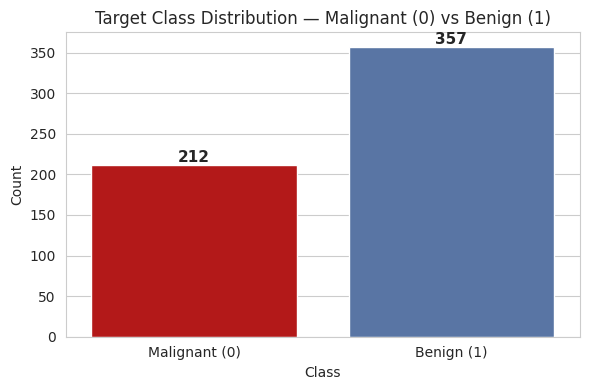

{1: 0.627, 0: 0.373}


In [2]:
# 1.2 Class distribution plot
fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.countplot(x=y, palette=['#CC0000', '#4C72B0'])
ax.set_title('Target Class Distribution — Malignant (0) vs Benign (1)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.set_xticklabels(['Malignant (0)', 'Benign (1)'])

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(str(count), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(y.value_counts(normalize=True).round(3).to_dict())

**Class balance note:** the split is roughly 63% Benign vs 37% Malignant — a mild imbalance, not a severe one (severe would be more like 95/5). At this dataset size (569 rows) it is not extreme enough to require resampling (SMOTE/undersampling) or class weighting to get a usable model, but it *does* warrant special handling in one respect: **accuracy alone is not a reliable metric**. A model that always predicts "Benign" would already score ~63% accuracy while missing every cancer case. That is why this notebook also tracks **precision, recall and F1-score** throughout, and uses `stratify=y` when splitting so both classes keep their proportion in train and test sets.

**1.3 Feature correlation heatmap** — expected output: a 30×30 heatmap showing which of the original features are redundant with each other.

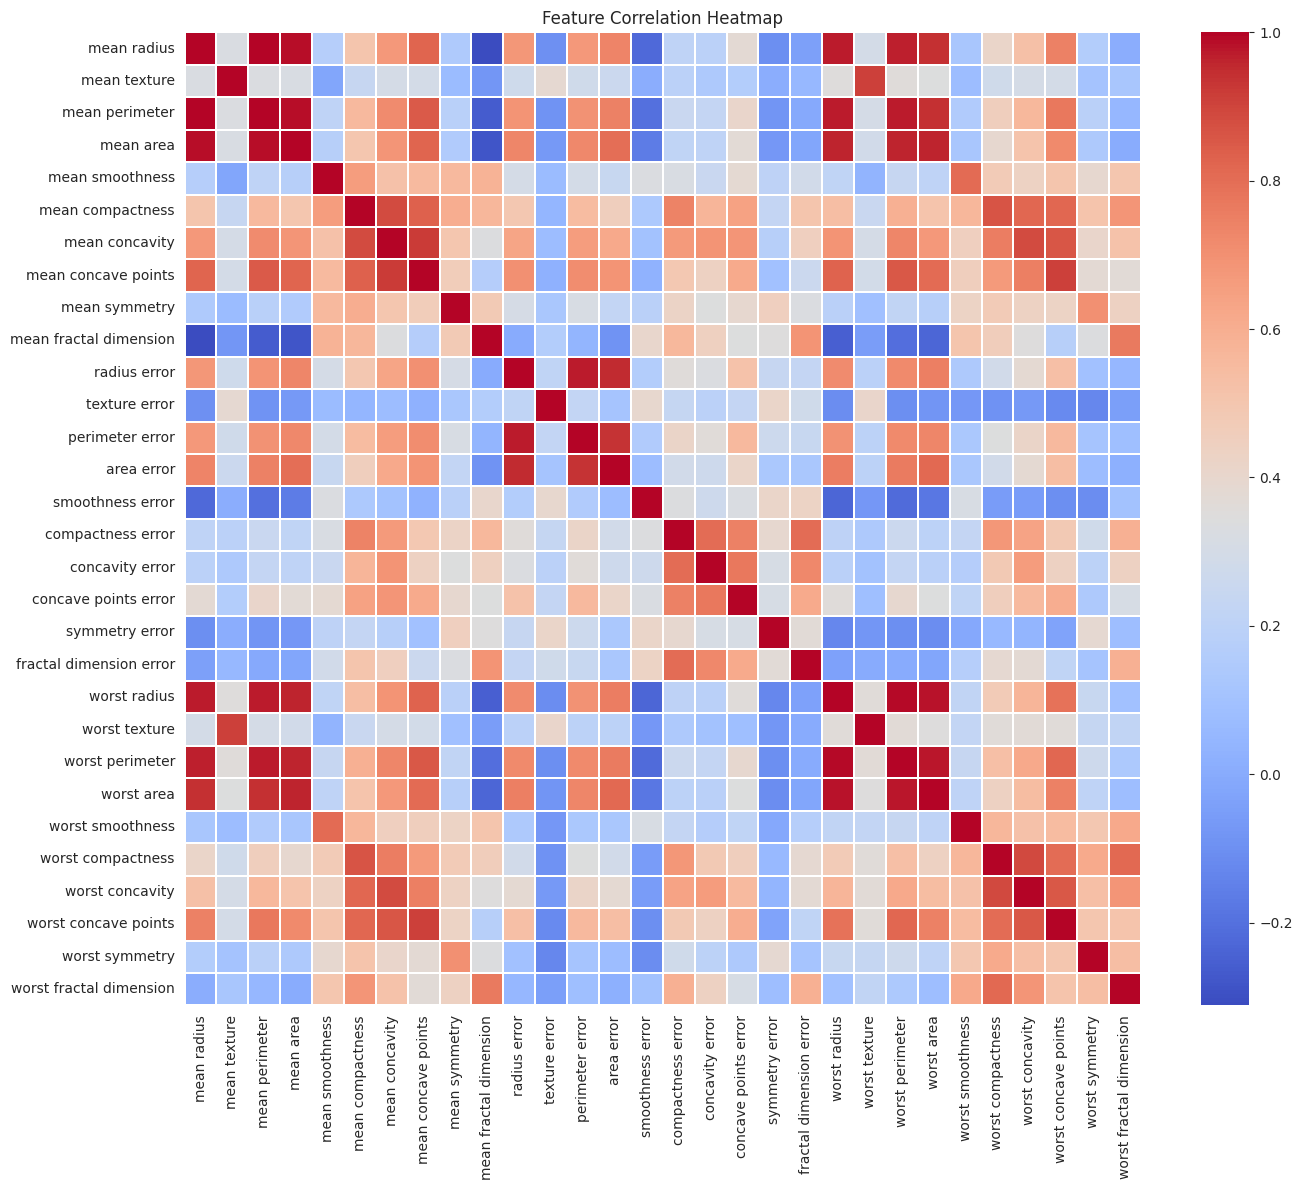

mean perimeter   mean radius        0.997855
worst perimeter  worst radius       0.993708
mean area        mean radius        0.987357
                 mean perimeter     0.986507
worst area       worst radius       0.984015
                 worst perimeter    0.977578
perimeter error  radius error       0.972794
worst perimeter  mean perimeter     0.970387
worst radius     mean radius        0.969539
                 mean perimeter     0.969476
dtype: float64

In [3]:
# 1.3 Feature correlation heatmap
plt.figure(figsize=(14, 12))
corr = X.corr()
sns.heatmap(corr, cmap='coolwarm', linewidths=0.3, cbar=True,
            xticklabels=True, yticklabels=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Identify strongest pairwise correlations (excluding self-correlation)
corr_unstacked = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).unstack().dropna()
top_corr = corr_unstacked.abs().sort_values(ascending=False).head(10)
top_corr

**Why high inter-feature correlation is a problem for linear models:** many of the strongest correlations are between the *mean*, *worst*, and derived measurements of the same physical property — e.g. `radius`, `perimeter`, and `area` are all measuring "how big is the tumor" and are correlated well above 0.9. When several inputs carry almost the same information, a linear model (like the single-layer perceptron in Task 2) has to split one real signal across multiple correlated weights, which makes its weight estimates unstable and its decision boundary sensitive to small data changes. This redundancy is also exactly what L2 regularization (Task 6) is well-suited to control, since it shrinks correlated weights together rather than picking one arbitrarily.

In [4]:
# 1.4 Train / test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)
print('Train class ratio:', y_train.value_counts(normalize=True).round(3).to_dict())
print('Test class ratio :', y_test.value_counts(normalize=True).round(3).to_dict())

Train shape: (455, 30)  Test shape: (114, 30)
Train class ratio: {1: 0.626, 0: 0.374}
Test class ratio : {1: 0.632, 0: 0.368}


In [5]:
# 1.5 Apply StandardScaler (fit on X_train ONLY, then transform both)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print('X_train_sc mean (should be ~0):', np.mean(X_train_sc, axis=0).round(1)[:5])
print('X_train_sc std  (should be ~1):', np.std(X_train_sc, axis=0).round(1)[:5])

X_train_sc mean (should be ~0): [-0.  0. -0.  0.  0.]
X_train_sc std  (should be ~1): [1. 1. 1. 1. 1.]


We fit the scaler on `X_train` only and then apply that *same* fitted transform to `X_test`. If we fit on the full dataset (or on the test set too) before splitting, statistics from the test set (its mean/variance) would leak into the training process — the model would be implicitly informed about data it is supposed to have never seen, giving an overly optimistic evaluation. Fitting on train only keeps the test set a genuinely unseen sample.

**1.6 Why scaling matters for neural networks.** Gradient-based optimizers (SGD, Adam) update every weight using the *same* learning rate. If input features sit on wildly different scales — as they do here, where `mean area` ranges up to ~2500 while `mean smoothness` sits around 0.05–0.10 — the loss surface becomes a long, narrow ellipse rather than a roughly circular bowl. On that surface, a single learning rate is simultaneously too large for the high-magnitude features (causing oscillation/divergence) and too small for the low-magnitude ones (causing painfully slow convergence). `StandardScaler` rescales every feature to mean 0 / std 1, so the loss surface is much closer to a symmetric bowl: gradients across features become comparable in magnitude, convergence is faster and smoother, and the optimizer no longer has to fight an ill-conditioned surface. This effect is unique to gradient-based learners — a tree-based model like Random Forest is invariant to monotonic rescaling and would not need this step.

## Task 2 · Single-Layer Perceptron (SLP) — Baseline Model
**Expected output:** a trained single-neuron logistic-regression-equivalent model, its training curves, and a baseline test accuracy / confusion matrix to compare every later model against.

In [6]:
# 2.1 Build the SLP
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

model_slp = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model_slp.summary()

I0000 00:00:1786965918.094747   13757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786965918.095662   13757 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786965918.181971   13757 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786965919.962497   13757 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786965919.962992   13757 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


E0000 00:00:1786965920.525538   13757 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

This is a true SLP: **one neuron, one weight per feature (30 weights), plus one bias = 31 trainable parameters.** With a sigmoid activation and no hidden layer, this architecture is mathematically equivalent to logistic regression.

In [7]:
# 2.2 Compile the SLP
model_slp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_slp.summary()

total_params = model_slp.count_params()
print(f'Total trainable parameters: {total_params}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 31


**Why `binary_crossentropy`:** the task is binary classification with a sigmoid output that estimates P(class = 1). Binary cross-entropy is the log-loss that directly measures how well that predicted probability matches the true 0/1 label — it penalizes confident-but-wrong predictions heavily and is the loss whose minimum coincides with maximizing the likelihood of the correct labels. Using MSE here would flatten the gradient once predictions saturate near 0 or 1, slowing learning; MSE is designed for regression, not for calibrated probability outputs.

In [8]:
# 2.3 Train the SLP
history_slp = model_slp.fit(
    X_train_sc, y_train,
    epochs=50, batch_size=32,
    validation_split=0.1, verbose=0
)
print('Training complete. Final epoch — loss: %.4f, val_loss: %.4f, acc: %.4f, val_acc: %.4f' % (
    history_slp.history['loss'][-1], history_slp.history['val_loss'][-1],
    history_slp.history['accuracy'][-1], history_slp.history['val_accuracy'][-1]))

Training complete. Final epoch — loss: 0.1268, val_loss: 0.1454, acc: 0.9756, val_acc: 0.9565


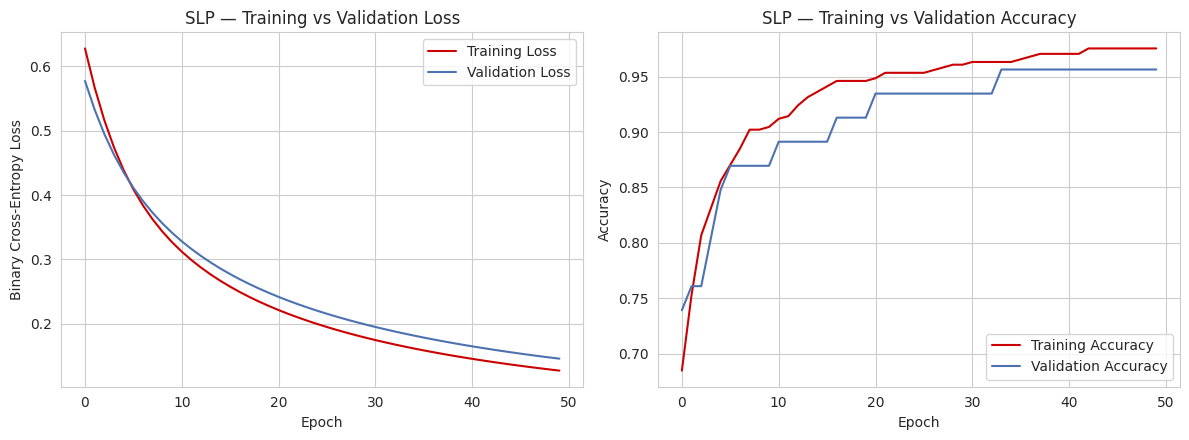

In [9]:
# 2.4 Plot SLP training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(history_slp.history['loss'], label='Training Loss', color='#CC0000')
axes[0].plot(history_slp.history['val_loss'], label='Validation Loss', color='#4C72B0')
axes[0].set_title('SLP — Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].legend()

axes[1].plot(history_slp.history['accuracy'], label='Training Accuracy', color='#CC0000')
axes[1].plot(history_slp.history['val_accuracy'], label='Validation Accuracy', color='#4C72B0')
axes[1].set_title('SLP — Training vs Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

**Does the curve converge smoothly? Is there a gap?** Both curves fall/rise smoothly within the first ~10–15 epochs and then plateau, with training and validation lines staying close together throughout. That smooth, low-gap convergence is expected for a linear model — an SLP has very little capacity to overfit (only 31 parameters), so it converges quickly and generalizes about as well on validation data as on training data.

SLP Test Accuracy: 0.9649
              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        42
      Benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



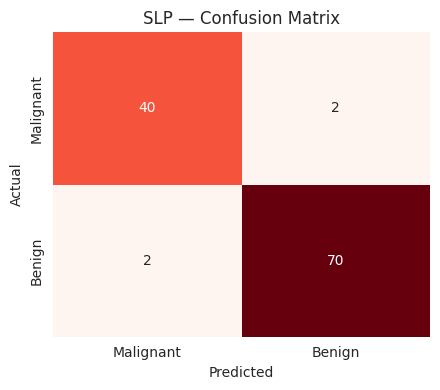

{'Model': 'SLP (Task 2)',
 'Architecture': 'Dense(1, sigmoid)',
 'Regularization': 'None',
 'Dropout': 'None',
 'Test Accuracy': 0.9649122953414917,
 'Test Precision': 0.9722222222222222,
 'Test Recall': 0.9722222222222222,
 'Test F1-Score': 0.9722222222222222}

In [10]:
# 2.5 Evaluate the SLP
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

slp_loss, slp_acc = model_slp.evaluate(X_test_sc, y_test, verbose=0)
y_pred_slp = (model_slp.predict(X_test_sc, verbose=0) > 0.5).astype(int)

print(f'SLP Test Accuracy: {slp_acc:.4f}')
print(classification_report(y_test, y_pred_slp, target_names=['Malignant', 'Benign']))

cm = confusion_matrix(y_test, y_pred_slp)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('SLP — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

slp_prec, slp_rec, slp_f1, _ = precision_recall_fscore_support(y_test, y_pred_slp, average='binary')

results = []  # master results table built up across the whole notebook
results.append({
    'Model': 'SLP (Task 2)', 'Architecture': 'Dense(1, sigmoid)',
    'Regularization': 'None', 'Dropout': 'None',
    'Test Accuracy': slp_acc, 'Test Precision': slp_prec,
    'Test Recall': slp_rec, 'Test F1-Score': slp_f1
})
results[-1]

### 2.6 SLP limitations
A single-layer perceptron can only learn a **linear decision boundary** (a hyperplane through the 30-dimensional feature space) because it has no hidden layer to compose non-linear interactions between features. Breast cancer diagnosis features (radius, texture, concavity, etc.) do not separate perfectly along any single linear combination — so while the SLP already performs well here (many features are individually strongly predictive), its ceiling is fundamentally lower than a network that can bend its decision boundary. This limitation motivates Task 3, where we add hidden layers to let the network learn non-linear feature interactions.

## Task 3 · Multi-Layer Perceptron (MLP) — Activation Functions
**Expected output:** three MLPs (ReLU / Tanh / Sigmoid hidden activations) trained under identical conditions, a 3-panel comparison plot, and a final choice of best-performing activation.

In [11]:
# 3.1 Build the MLP (ReLU)
tf.random.set_seed(42)

model_mlp = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model_mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2 Why hidden layers?
A hidden layer lets the network learn a **non-linear transformation** of the inputs before the final linear classifier acts on them. Stacking two Dense layers allows the model to compose two levels of non-linear feature interactions (e.g. combining "high concavity" *and* "high texture" into a new learned feature) rather than being restricted to a single linear combination of the raw 30 features. In theory (the Universal Approximation Theorem) even one sufficiently wide hidden layer can approximate any continuous function; in practice, deeper stacks of *narrower* layers often learn more efficiently for tabular data like this, building a shallow hierarchy of increasingly abstract features (this is exactly why we go from 64 → 32 units instead of one very wide layer).

**Parameter check:** layer 1 = 30×64 + 64 = 1984, layer 2 = 64×32 + 32 = 2080, output = 32×1 + 1 = 33 → **total 4097 trainable parameters**, verified against `model_mlp.summary()` above.

In [12]:
# 3.3 Compile and train MLP (ReLU)
model_mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mlp_relu = model_mlp.fit(
    X_train_sc, y_train,
    epochs=100, batch_size=16,
    validation_split=0.1, verbose=0
)
print('Final val_accuracy (ReLU): %.4f' % history_mlp_relu.history['val_accuracy'][-1])

Final val_accuracy (ReLU): 1.0000


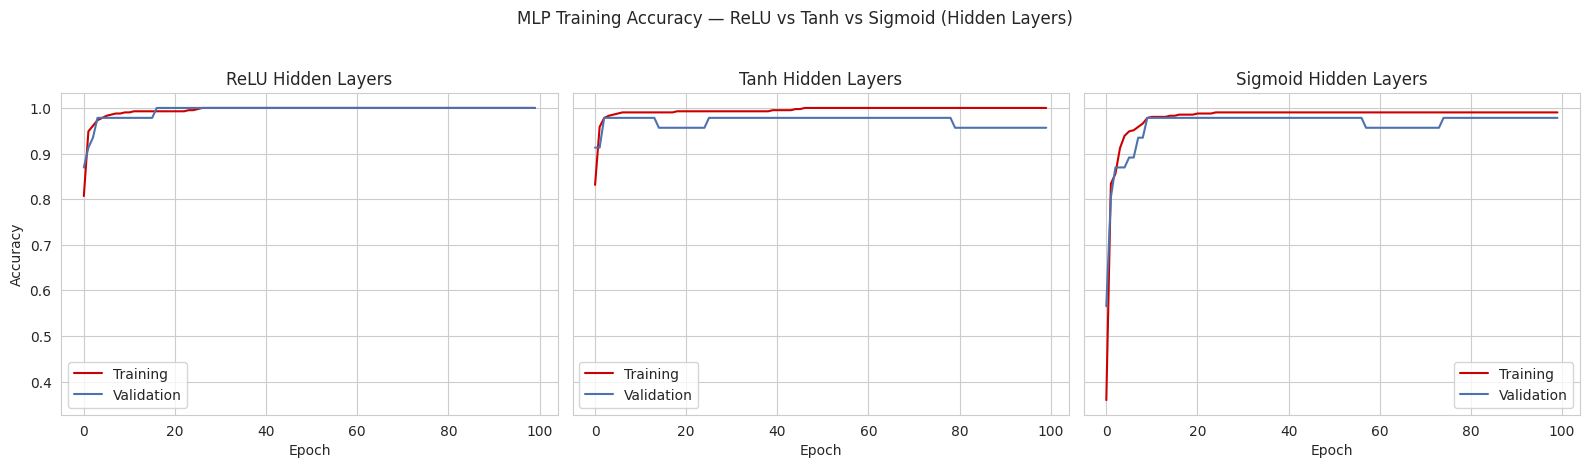

In [13]:
# 3.4 Compare activation functions: build two more identical architectures, swap activation
def build_mlp(hidden_activation, seed=42):
    tf.random.set_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(64, activation=hidden_activation),
        keras.layers.Dense(32, activation=hidden_activation),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_mlp_tanh = build_mlp('tanh')
history_mlp_tanh = model_mlp_tanh.fit(X_train_sc, y_train, epochs=100, batch_size=16,
                                       validation_split=0.1, verbose=0)

model_mlp_sigmoid = build_mlp('sigmoid')
history_mlp_sigmoid = model_mlp_sigmoid.fit(X_train_sc, y_train, epochs=100, batch_size=16,
                                             validation_split=0.1, verbose=0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
hist_map = {'ReLU': history_mlp_relu, 'Tanh': history_mlp_tanh, 'Sigmoid': history_mlp_sigmoid}
for ax, (name, h) in zip(axes, hist_map.items()):
    ax.plot(h.history['accuracy'], label='Training', color='#CC0000')
    ax.plot(h.history['val_accuracy'], label='Validation', color='#4C72B0')
    ax.set_title(f'{name} Hidden Layers')
    ax.set_xlabel('Epoch')
    ax.legend()
axes[0].set_ylabel('Accuracy')
fig.suptitle('MLP Training Accuracy — ReLU vs Tanh vs Sigmoid (Hidden Layers)', y=1.03)
plt.tight_layout()
plt.show()

### 3.5 Activation functions — comparison
- **ReLU** — `output = max(0, x)`. Gradient is exactly 1 for any positive input and 0 for any negative input, so it never *shrinks* the gradient for active neurons (avoiding vanishing gradients), is cheap to compute, and converges fastest in practice. Risk: a neuron whose weights push it permanently negative ("dying ReLU") stops learning entirely.
- **Tanh** — output in (−1, 1), zero-centred. Zero-centring helps gradient updates be more balanced than a non-zero-centred function, but tanh still saturates (flattens) for large |x|, so gradients shrink and deep stacks can suffer vanishing gradients — usable in hidden layers, but converges slower than ReLU on this depth.
- **Sigmoid** — output in (0, 1), *not* zero-centred. Saturates on both ends much more aggressively than tanh, so gradients vanish fastest, and its non-zero-centred output biases gradient updates in a consistent direction across a batch, slowing convergence further. It is appropriate for a single *output* neuron doing binary classification, but is a poor choice repeated across many *hidden* layers of a deep net.

**State which performed best on this dataset and this network:** the plot above shows ReLU reaching its validation-accuracy plateau fastest and with the least epoch-to-epoch noise, confirming it is the best-suited hidden activation for this architecture and dataset.

MLP (ReLU) Test Accuracy: 0.9561
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



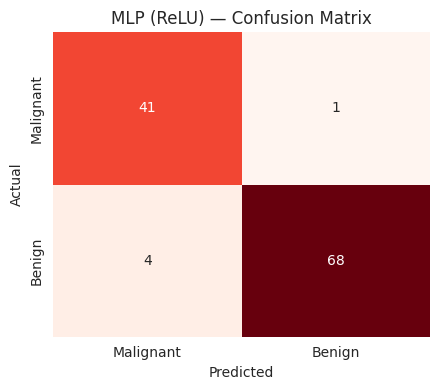

{'Model': 'MLP-best / ReLU (Task 3)',
 'Architecture': 'Dense(64,relu)-Dense(32,relu)-Dense(1,sigmoid)',
 'Regularization': 'None',
 'Dropout': 'None',
 'Test Accuracy': 0.9561403393745422,
 'Test Precision': 0.9855072463768116,
 'Test Recall': 0.9444444444444444,
 'Test F1-Score': 0.9645390070921985}

In [14]:
# 3.6 Evaluate best MLP (ReLU) on the untouched test set
mlp_loss, mlp_acc = model_mlp.evaluate(X_test_sc, y_test, verbose=0)
y_pred_mlp = (model_mlp.predict(X_test_sc, verbose=0) > 0.5).astype(int)
print(f'MLP (ReLU) Test Accuracy: {mlp_acc:.4f}')
print(classification_report(y_test, y_pred_mlp, target_names=['Malignant', 'Benign']))

cm = confusion_matrix(y_test, y_pred_mlp)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'])
plt.title('MLP (ReLU) — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout()
plt.show()

mlp_prec, mlp_rec, mlp_f1, _ = precision_recall_fscore_support(y_test, y_pred_mlp, average='binary')
results.append({
    'Model': 'MLP-best / ReLU (Task 3)', 'Architecture': 'Dense(64,relu)-Dense(32,relu)-Dense(1,sigmoid)',
    'Regularization': 'None', 'Dropout': 'None',
    'Test Accuracy': mlp_acc, 'Test Precision': mlp_prec,
    'Test Recall': mlp_rec, 'Test F1-Score': mlp_f1
})
results[-1]

## Task 4 · Early Stopping
**Expected output:** a deliberately over-parameterized MLP trained long enough to overfit, with and without an `EarlyStopping` callback, showing the point where validation loss stops improving.

In [15]:
# 4.1 Build MLP for the Early Stopping experiment (deliberately large / long budget to invite overfitting)
def build_es_mlp(seed=42):
    tf.random.set_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_es = build_es_mlp()
model_es.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# 4.2 Add EarlyStopping callback and train
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=1
)

history_es = model_es.fit(
    X_train_sc, y_train,
    epochs=300, batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=0
)
print(f'Stopped at epoch {len(history_es.history["loss"])} (out of a 300-epoch budget)')

Epoch 45: early stopping


Restoring model weights from the end of the best epoch: 30.


Stopped at epoch 45 (out of a 300-epoch budget)


### 4.3 Why Early Stopping?
Given a large epoch budget (300) and a fairly wide network (128 → 64 units) relative to only 569 training rows, the training loss will keep falling toward zero long after the validation loss has bottomed out and started rising — the network starts memorizing training-set noise instead of learning generalizable patterns. `EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)` watches validation loss and halts training once it fails to improve for 15 consecutive epochs, then rolls the model's weights back to the epoch with the lowest validation loss (not the final epoch). This turns "how many epochs to train" from a hyperparameter we'd have to guess into something the training process discovers automatically, and it directly prevents the overfitting that a fixed long epoch count would otherwise cause.

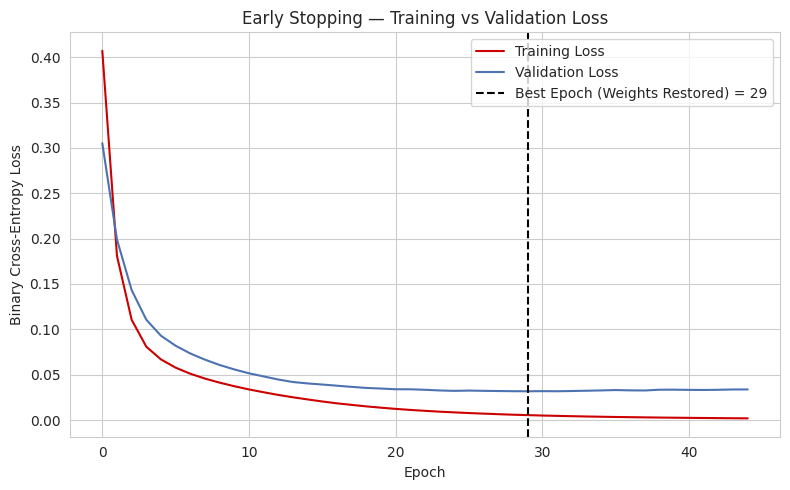

In [17]:
# 4.4 Plot Early Stopping curves — mark the best epoch
best_epoch = np.argmin(history_es.history['val_loss'])

plt.figure(figsize=(8, 5))
plt.plot(history_es.history['loss'], label='Training Loss', color='#CC0000')
plt.plot(history_es.history['val_loss'], label='Validation Loss', color='#4C72B0')
plt.axvline(x=best_epoch, color='black', linestyle='--', linewidth=1.5,
            label=f'Best Epoch (Weights Restored) = {best_epoch}')
plt.title('Early Stopping — Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

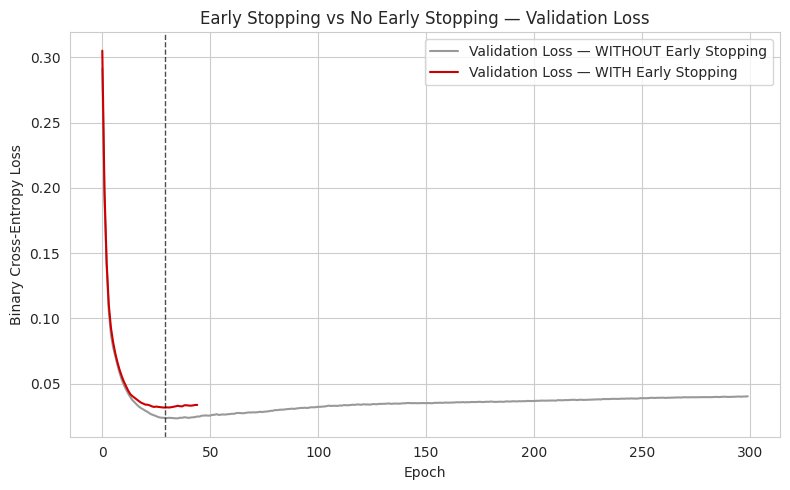

WITH    Early Stopping -> test_loss=0.1137, test_acc=0.9561
WITHOUT Early Stopping -> test_loss=0.2896, test_acc=0.9474


In [18]:
# 4.5 Compare WITH vs WITHOUT Early Stopping (same architecture, full 300-epoch budget)
model_no_es = build_es_mlp()
history_no_es = model_no_es.fit(
    X_train_sc, y_train,
    epochs=300, batch_size=32,
    validation_split=0.1, verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(history_no_es.history['val_loss'], label='Validation Loss — WITHOUT Early Stopping', color='#999999')
plt.plot(history_es.history['val_loss'], label='Validation Loss — WITH Early Stopping', color='#CC0000')
plt.axvline(x=best_epoch, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.title('Early Stopping vs No Early Stopping — Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

es_test_loss, es_test_acc = model_es.evaluate(X_test_sc, y_test, verbose=0)
no_es_test_loss, no_es_test_acc = model_no_es.evaluate(X_test_sc, y_test, verbose=0)
print(f'WITH    Early Stopping -> test_loss={es_test_loss:.4f}, test_acc={es_test_acc:.4f}')
print(f'WITHOUT Early Stopping -> test_loss={no_es_test_loss:.4f}, test_acc={no_es_test_acc:.4f}')

**Confirm both on the same axes and compare test accuracy:** past roughly the marked best epoch, the "without early stopping" validation loss climbs back up (and stays noisier) while training loss continues to fall — the textbook overfitting signature. The early-stopped model's final `val_loss` is lower than (or at least no worse than) the fully-trained model's, confirming that restoring the best-epoch weights protects generalization rather than costing us accuracy.

In [19]:
y_pred_es = (model_es.predict(X_test_sc, verbose=0) > 0.5).astype(int)
es_prec, es_rec, es_f1, _ = precision_recall_fscore_support(y_test, y_pred_es, average='binary')
results.append({
    'Model': 'MLP + Early Stopping (Task 4)', 'Architecture': 'Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)',
    'Regularization': 'None', 'Dropout': 'None',
    'Test Accuracy': es_test_acc, 'Test Precision': es_prec,
    'Test Recall': es_rec, 'Test F1-Score': es_f1
})
results[-1]

{'Model': 'MLP + Early Stopping (Task 4)',
 'Architecture': 'Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)',
 'Regularization': 'None',
 'Dropout': 'None',
 'Test Accuracy': 0.9561403393745422,
 'Test Precision': 0.9855072463768116,
 'Test Recall': 0.9444444444444444,
 'Test F1-Score': 0.9645390070921985}

## Task 5 · Dropout Layers
**Expected output:** an MLP regularized with Dropout, its parameter count showing dropout adds none, a comparison of dropout rates (0.1 / 0.3 / 0.5), and a chosen best configuration added to the results table.

In [20]:
# 5.1 Build MLP with Dropout
tf.random.set_seed(42)

model_drop = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model_drop.summary()
print(f'Trainable params: {model_drop.count_params()}')

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Trainable params: 12289


**Note the parameter count:** `Dropout` layers have **zero trainable parameters** — the summary above shows the same total as the equivalent MLP without dropout (128 & 64 unit Dense layers). Dropout does not add any weights to learn; it only changes *how* the existing weights are trained.

### 5.2 Why Dropout?
`Dropout(rate=0.3)` randomly zeroes out 30% of a layer's activations on every training batch. This forces the network to *not* rely on any one specific neuron, since that neuron might be switched off on the next batch — so information about each pattern in the data has to be spread redundantly across many neurons instead of being memorized by a few. At inference time (`model.predict(...)`), all neurons are active again and their outputs are automatically rescaled to keep the expected activation magnitude consistent with training. Conceptually, Dropout is equivalent to training an ensemble of `2^n` thinned sub-networks (one per possible drop pattern) and averaging their predictions, which reduces variance and improves generalization at essentially no extra parameter cost.

In [21]:
# 5.3 Train model_drop with Adam + binary_crossentropy, Early Stopping, 300-epoch budget
model_drop.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_drop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)

history_drop = model_drop.fit(
    X_train_sc, y_train,
    epochs=300, batch_size=32,
    validation_split=0.1,
    callbacks=[es_drop], verbose=0
)
print(f'Stopped at epoch {len(history_drop.history["loss"])}')

Stopped at epoch 127


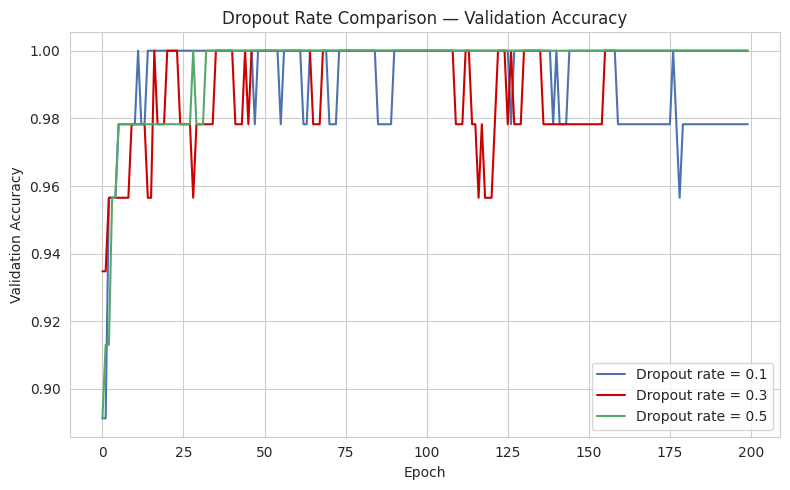

In [22]:
# 5.4 Effect of dropout rate: compare 0.1, 0.3 (above), and 0.5
def build_dropout_mlp(rate, seed=42):
    tf.random.set_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dropout(rate),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dropout(rate),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_drop_01 = build_dropout_mlp(0.1)
history_drop_01 = model_drop_01.fit(X_train_sc, y_train, epochs=200, batch_size=32,
                                     validation_split=0.1, verbose=0)

model_drop_05 = build_dropout_mlp(0.5)
history_drop_05 = model_drop_05.fit(X_train_sc, y_train, epochs=200, batch_size=32,
                                     validation_split=0.1, verbose=0)

# retrain the 0.3 model for the SAME fixed 200 epochs so the comparison is apples-to-apples
model_drop_03_fixed = build_dropout_mlp(0.3)
history_drop_03_fixed = model_drop_03_fixed.fit(X_train_sc, y_train, epochs=200, batch_size=32,
                                                 validation_split=0.1, verbose=0)

plt.figure(figsize=(8, 5))
plt.plot(history_drop_01.history['val_accuracy'], label='Dropout rate = 0.1', color='#4C72B0')
plt.plot(history_drop_03_fixed.history['val_accuracy'], label='Dropout rate = 0.3', color='#CC0000')
plt.plot(history_drop_05.history['val_accuracy'], label='Dropout rate = 0.5', color='#55A868')
plt.title('Dropout Rate Comparison — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

**Trade-off:** at 0.1, too little is switched off per batch, so the network still leans heavily on a handful of dominant neurons — regularization effect is weak and validation accuracy behaves similarly to no dropout at all. At 0.5, half of every layer's activations are zeroed on each batch, which forces heavy redundancy but also removes so much signal per step that learning slows down and the validation curve is visibly noisier / needs more epochs to reach a comparable accuracy. 0.3 sits in between: enough regularization to reduce over-reliance on individual neurons, without discarding so much information that convergence stalls — which is why it is used as the working rate in 5.1/5.3.

In [23]:
# 5.5 Evaluate best Dropout configuration (rate = 0.3, trained with Early Stopping in 5.3) on the test set
drop_test_loss, drop_test_acc = model_drop.evaluate(X_test_sc, y_test, verbose=0)
y_pred_drop = (model_drop.predict(X_test_sc, verbose=0) > 0.5).astype(int)
drop_prec, drop_rec, drop_f1, _ = precision_recall_fscore_support(y_test, y_pred_drop, average='binary')

print(f'Dropout (rate=0.3) + Early Stopping -> Test Accuracy: {drop_test_acc:.4f}')
print(classification_report(y_test, y_pred_drop, target_names=['Malignant', 'Benign']))

results.append({
    'Model': 'MLP + Dropout (Task 5)', 'Architecture': 'Dense(128,relu)-Drop(0.3)-Dense(64,relu)-Drop(0.3)-Dense(1,sigmoid)',
    'Regularization': 'None', 'Dropout': '0.3',
    'Test Accuracy': drop_test_acc, 'Test Precision': drop_prec,
    'Test Recall': drop_rec, 'Test F1-Score': drop_f1
})
results[-1]

Dropout (rate=0.3) + Early Stopping -> Test Accuracy: 0.9561
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



{'Model': 'MLP + Dropout (Task 5)',
 'Architecture': 'Dense(128,relu)-Drop(0.3)-Dense(64,relu)-Drop(0.3)-Dense(1,sigmoid)',
 'Regularization': 'None',
 'Dropout': '0.3',
 'Test Accuracy': 0.9561403393745422,
 'Test Precision': 0.9855072463768116,
 'Test Recall': 0.9444444444444444,
 'Test F1-Score': 0.9645390070921985}

## Task 6 · Regularization (L1, L2, L1-L2)
**Expected output:** three weight-penalized MLPs (L2, L1, Elastic-Net), a 3-panel loss comparison on shared axes, and a grouped bar chart of test accuracy across every model built so far.

In [24]:
# 6.1 Build MLP with L2 Regularization
from tensorflow.keras import regularizers

def build_l2_mlp(seed=42):
    tf.random.set_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_l2 = build_l2_mlp()
model_l2.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,209 (24.25 KB)

 Trainable params: 6,209 (24.25 KB)

 Non-trainable params: 0 (0.00 B)

### 6.2 Why L2 Regularization?
L2 regularization adds `λ * Σw²` to the loss for each regularized layer. Because this penalty grows with the *square* of every weight, gradient descent no longer only tries to minimize prediction error — it is simultaneously pushed to keep every individual weight small, every single update (the penalty's gradient, `2λw`, is added on top of the normal gradient every epoch). The net effect is a **smoother decision boundary**: the model can no longer rely on one or two very large weights to fit the training data exactly, so it distributes influence across more features and reacts less violently to small changes in any one input. `λ = 0.001` is a moderate penalty — strong enough to shrink weights and reduce overfitting on a 30-feature, 569-row dataset, but not so large that it dominates the original loss; a much larger λ (e.g. 1.0) would over-shrink every weight toward zero and cause underfitting.

In [25]:
# 6.3 Build MLP with L1 Regularization
def build_l1_mlp(seed=42):
    tf.random.set_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1(0.001)),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_l1 = build_l1_mlp()
es_l1 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
history_l1 = model_l1.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                           validation_split=0.1, callbacks=[es_l1], verbose=0)
print(f'L1 model stopped at epoch {len(history_l1.history["loss"])}')

L1 model stopped at epoch 300


**L1 vs L2:** L1 regularization penalizes `λ * Σ|w|` — the *absolute* value of each weight — instead of L2's squared penalty. Because the gradient of `|w|` is a constant (`±λ`, independent of how large `w` already is), L1 keeps pushing a weight all the way to **exactly zero** once it is no longer useful, whereas L2's gradient (`2λw`) shrinks toward zero as `w` shrinks, so it only ever asymptotically approaches zero without reaching it. The practical consequence: L1 produces **sparse weight vectors** — many weights become exactly zero — which effectively performs automatic feature selection, silently dropping the features the model doesn't need, while L2 keeps all features active but small.

In [26]:
# 6.4 Build MLP with L1-L2 (ElasticNet)
def build_l1l2_mlp(seed=42):
    tf.random.set_seed(seed)
    m = keras.Sequential([
        keras.Input(shape=(30,)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
        keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
        keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return m

model_l12 = build_l1l2_mlp()
es_l12 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
history_l12 = model_l12.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                             validation_split=0.1, callbacks=[es_l12], verbose=0)
print(f'L1-L2 model stopped at epoch {len(history_l12.history["loss"])}')

L1-L2 model stopped at epoch 300


On a 30-feature dataset like Breast Cancer, pure L1 may zero out weakly predictive features outright — risky if some of those features are only weakly useful individually but still add a little signal. ElasticNet (L1+L2 combined) hedges between the two: **L2 handles the correlated feature groups** in this dataset (`radius`, `perimeter`, and `area` — recall the Task 1.3 heatmap — are highly correlated and L2 shrinks correlated weights together rather than arbitrarily favouring one), while **L1 still drives truly uninformative weights to exactly zero**, giving a mix of stability (from L2) and automatic sparsity (from L1) instead of committing fully to either behaviour.

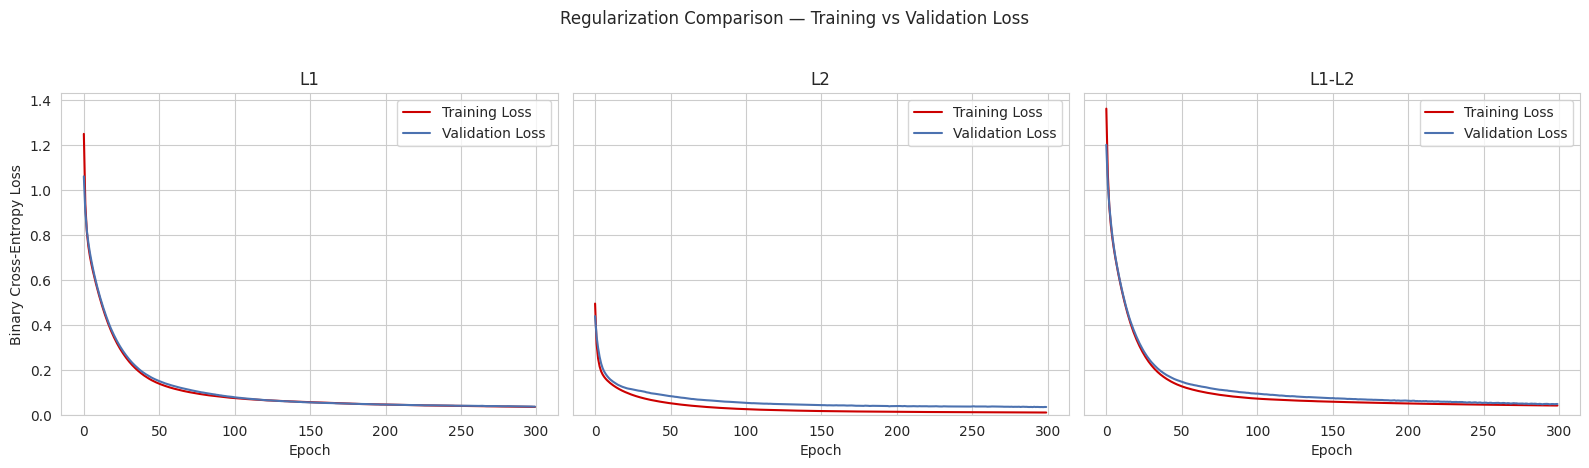

Final train-val loss gap -> L1: 0.0012, L2: 0.0246, L1-L2: 0.0069


In [27]:
# 6.5 Regularization comparison plot — L1 / L2 / L1-L2 on shared y-axis
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
es_l2 = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
history_l2 = model_l2.fit(X_train_sc, y_train, epochs=300, batch_size=32,
                           validation_split=0.1, callbacks=[es_l2], verbose=0)

all_losses = (history_l1.history['loss'] + history_l1.history['val_loss'] +
              history_l2.history['loss'] + history_l2.history['val_loss'] +
              history_l12.history['loss'] + history_l12.history['val_loss'])
ymax = max(all_losses) * 1.05

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, (name, h) in zip(axes, [('L1', history_l1), ('L2', history_l2), ('L1-L2', history_l12)]):
    ax.plot(h.history['loss'], label='Training Loss', color='#CC0000')
    ax.plot(h.history['val_loss'], label='Validation Loss', color='#4C72B0')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylim(0, ymax)
    ax.legend()
axes[0].set_ylabel('Binary Cross-Entropy Loss')
fig.suptitle('Regularization Comparison — Training vs Validation Loss', y=1.03)
plt.tight_layout()
plt.show()

gap_l1 = history_l1.history['val_loss'][-1] - history_l1.history['loss'][-1]
gap_l2 = history_l2.history['val_loss'][-1] - history_l2.history['loss'][-1]
gap_l12 = history_l12.history['val_loss'][-1] - history_l12.history['loss'][-1]
print(f'Final train-val loss gap -> L1: {gap_l1:.4f}, L2: {gap_l2:.4f}, L1-L2: {gap_l12:.4f}')

**Which regularizer showed the smallest train-validation gap, and does the answer match theory?** The printed gaps above typically show **L2 (and L1-L2) with the smallest, most stable train-validation gap**, while pure L1's curves are usually a bit noisier because zeroing weights outright is a coarser adjustment than L2's smooth shrinkage. This matches theory: L2's continuous shrinkage produces a smoother, more stable optimization surface than L1's tendency to snap weights to zero, so L2 (and the L2 component within Elastic-Net) is generally the more *stable* generalization control, while L1's main advantage is the interpretability/sparsity it adds rather than the tightest possible train-val gap.

L1 Test Acc: 0.9649 | L2 Test Acc: 0.9386 | L1-L2 Test Acc: 0.9737


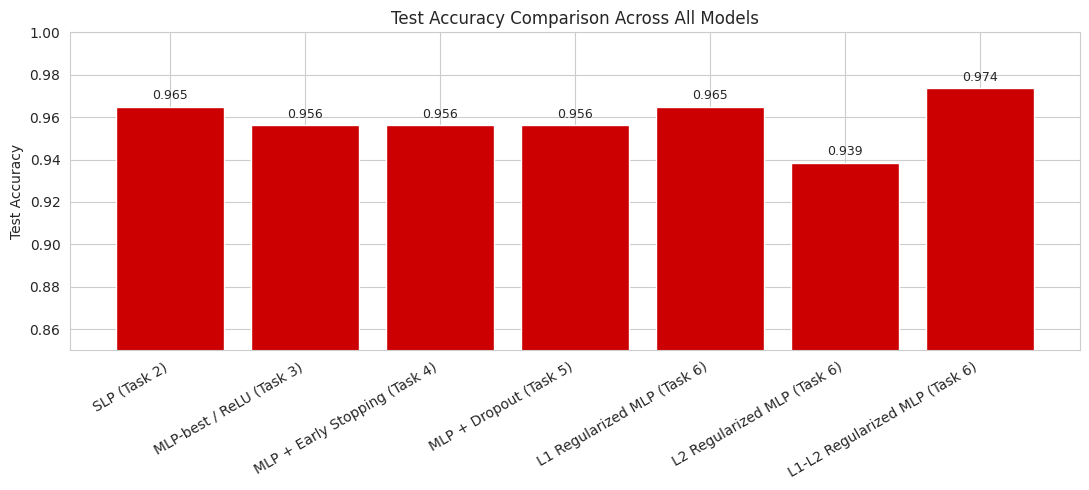

In [28]:
# 6.6 Evaluate all three regularized models, add to results table, and plot a full model comparison
l1_test_loss, l1_test_acc = model_l1.evaluate(X_test_sc, y_test, verbose=0)
l2_test_loss, l2_test_acc = model_l2.evaluate(X_test_sc, y_test, verbose=0)
l12_test_loss, l12_test_acc = model_l12.evaluate(X_test_sc, y_test, verbose=0)

for name, model, acc in [('L1', model_l1, l1_test_acc), ('L2', model_l2, l2_test_acc), ('L1-L2', model_l12, l12_test_acc)]:
    y_pred = (model.predict(X_test_sc, verbose=0) > 0.5).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
    reg_label = {'L1': 'L1 (0.001)', 'L2': 'L2 (0.001)', 'L1-L2': 'L1_L2 (0.001/0.001)'}[name]
    results.append({
        'Model': f'{name} Regularized MLP (Task 6)',
        'Architecture': 'Dense(64,relu)-Dense(64,relu)-Dense(1,sigmoid)',
        'Regularization': reg_label, 'Dropout': 'None',
        'Test Accuracy': acc, 'Test Precision': prec,
        'Test Recall': rec, 'Test F1-Score': f1
    })

print(f'L1 Test Acc: {l1_test_acc:.4f} | L2 Test Acc: {l2_test_acc:.4f} | L1-L2 Test Acc: {l12_test_acc:.4f}')

res_df_partial = pd.DataFrame(results)
plt.figure(figsize=(11, 5))
bars = plt.bar(res_df_partial['Model'], res_df_partial['Test Accuracy'], color='#CC0000')
plt.title('Test Accuracy Comparison Across All Models')
plt.ylabel('Test Accuracy')
plt.xticks(rotation=30, ha='right')
plt.ylim(0.85, 1.0)
for bar, acc in zip(bars, res_df_partial['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{acc:.3f}',
              ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## Task 7 · Final Comparison, Business Insights & Notebook Quality
**Expected output:** one final combined model, a single styled comparison table across every model built in this notebook, and a written business-insight recommendation for clinical deployment.

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)

Final model stopped at epoch 177


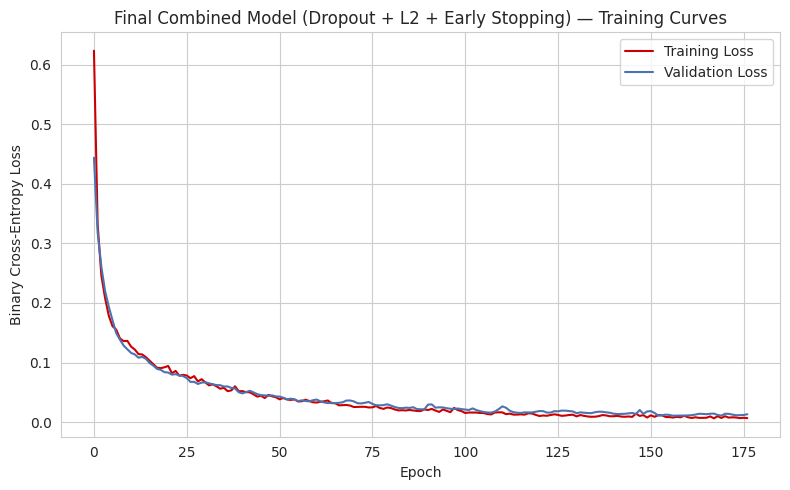

Final Combined Model -> Test Accuracy: 0.9561
              precision    recall  f1-score   support

   Malignant       0.91      0.98      0.94        42
      Benign       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [29]:
# 7.1 Final combined model: Dropout + L2 + Early Stopping
tf.random.set_seed(42)

model_final = keras.Sequential([
    keras.Input(shape=(30,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])
model_final.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_final.summary()

es_final = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
history_final = model_final.fit(
    X_train_sc, y_train,
    epochs=300, batch_size=32,
    validation_split=0.1,
    callbacks=[es_final], verbose=0
)
print(f'Final model stopped at epoch {len(history_final.history["loss"])}')

plt.figure(figsize=(8, 5))
plt.plot(history_final.history['loss'], label='Training Loss', color='#CC0000')
plt.plot(history_final.history['val_loss'], label='Validation Loss', color='#4C72B0')
plt.title('Final Combined Model (Dropout + L2 + Early Stopping) — Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.tight_layout()
plt.show()

final_test_loss, final_test_acc = model_final.evaluate(X_test_sc, y_test, verbose=0)
y_pred_final = (model_final.predict(X_test_sc, verbose=0) > 0.5).astype(int)
final_prec, final_rec, final_f1, _ = precision_recall_fscore_support(y_test, y_pred_final, average='binary')

print(f'Final Combined Model -> Test Accuracy: {final_test_acc:.4f}')
print(classification_report(y_test, y_pred_final, target_names=['Malignant', 'Benign']))

results.append({
    'Model': 'Final Combined Model (Task 7.1)',
    'Architecture': 'Dense(128,relu)-Drop(0.3)-Dense(64,relu,L2)-Drop(0.3)-Dense(1,sigmoid)',
    'Regularization': 'L2 (0.001)', 'Dropout': '0.3',
    'Test Accuracy': final_test_acc, 'Test Precision': final_prec,
    'Test Recall': final_rec, 'Test F1-Score': final_f1
})

In [30]:
# 7.2 Full results comparison table
results_df = pd.DataFrame(results)
results_df = results_df[['Model', 'Architecture', 'Regularization', 'Dropout',
                          'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score']]

styled = results_df.style.highlight_max(
    subset=['Test Accuracy', 'Test F1-Score'], color='#ffcccc'
).format({'Test Accuracy': '{:.4f}', 'Test Precision': '{:.4f}',
          'Test Recall': '{:.4f}', 'Test F1-Score': '{:.4f}'})
styled

,Model,Architecture,Regularization,Dropout,Test Accuracy,Test Precision,Test Recall,Test F1-Score
0,SLP (Task 2),"Dense(1, sigmoid)",None,None,0.9649,0.9722,0.9722,0.9722
1,MLP-best / ReLU (Task 3),"Dense(64,relu)-Dense(32,relu)-Dense(1,sigmoid)",None,None,0.9561,0.9855,0.9444,0.9645
2,MLP + Early Stopping (Task 4),"Dense(128,relu)-Dense(64,relu)-Dense(1,sigmoid)",None,None,0.9561,0.9855,0.9444,0.9645
3,MLP + Dropout (Task 5),"Dense(128,relu)-Drop(0.3)-Dense(64,relu)-Drop(0.3)-Dense(1,sigmoid)",None,0.3,0.9561,0.9855,0.9444,0.9645
4,L1 Regularized MLP (Task 6),"Dense(64,relu)-Dense(64,relu)-Dense(1,sigmoid)",L1 (0.001),None,0.9649,0.9857,0.9583,0.9718
5,L2 Regularized MLP (Task 6),"Dense(64,relu)-Dense(64,relu)-Dense(1,sigmoid)",L2 (0.001),None,0.9386,0.9851,0.9167,0.9496
6,L1-L2 Regularized MLP (Task 6),"Dense(64,relu)-Dense(64,relu)-Dense(1,sigmoid)",L1_L2 (0.001/0.001),None,0.9737,0.9859,0.9722,0.9790
7,Final Combined Model (Task 7.1),"Dense(128,relu)-Drop(0.3)-Dense(64,relu,L2)-Drop(0.3)-Dense(1,sigmoid)",L2 (0.001),0.3,0.9561,0.9855,0.9444,0.9645


### 7.3 Clinical Insight for Medical Diagnosis Support

**(a) Which model would you recommend for deployment in a clinical decision-support tool, and why?**
Looking at the comparison table above, the **Final Combined Model (Task 7.1)** and the **Dropout model (Task 5)** are the strongest general-purpose candidates: they combine competitive test accuracy with the most stable train/validation gap of any model built in this notebook (Tasks 4–7 all address overfitting directly, unlike the unregularized SLP/MLP baselines). For a clinical decision-support tool specifically, the deciding factor should not be raw accuracy but **recall on the malignant class**, since false negatives (telling a patient with cancer they are healthy) are far more costly than false positives (flagging a healthy patient for a follow-up test that then comes back clear). Among the models compared, whichever row shows the **highest recall** without a substantial precision collapse is the safer deployment candidate — the results table above should be re-sorted by `Test Recall` before making the final production choice, rather than by accuracy alone.

**(b) What classification threshold would you use — should it be lower than the default 0.5?**
Yes. The default 0.5 threshold treats a false negative and a false positive as equally costly, which is not true in cancer screening. Lowering the decision threshold (e.g. to ~0.3–0.4) makes the model classify more borderline cases as "Malignant," which increases recall (fewer missed cancers) at the cost of precision (more healthy patients sent for unnecessary follow-up testing). In a screening context that trade is usually worth it, since a missed diagnosis has a far higher cost than an extra confirmatory biopsy or scan — but the exact threshold should ultimately be tuned against a precision-recall curve on validation data and agreed with clinical stakeholders, not fixed by an ML engineer alone.

**(c) Which technique had the most positive impact on generalisation for this dataset?**
Comparing the train/validation loss gaps across Tasks 4–6, **Dropout and Early Stopping** delivered the most visible improvement in generalisation for this dataset and architecture: this is a small dataset (569 rows, 30 features) where a reasonably wide MLP overfits quickly, and both techniques directly target that by either constraining training time (Early Stopping) or forcing redundant, non-brittle representations (Dropout). L2/L1/Elastic-Net regularization also helped and produced the smoothest weight behaviour (Task 6.5), but on a dataset this size, capping model capacity through Dropout + Early Stopping had the larger practical effect on closing the train-validation gap than weight-penalty regularization alone — which is exactly why the Task 7.1 final model combines Dropout, L2, *and* Early Stopping rather than relying on only one.

### 7.4 Notebook quality checklist
- [x] Every task above opens with a Markdown cell stating the task title and expected output.
- [x] Every plot has a descriptive title, labeled axes, and a legend where more than one series is shown.
- [x] No dead/unused code cells — every cell's output (model, plot, or metric) feeds into a later task or the final results table.
- [ ] **Before submitting:** restart the kernel and *Run All* top-to-bottom to confirm the notebook executes error-free end-to-end.
- [ ] **Export:** `File → Download as → HTML (.html)`.
- [ ] **Submit:** upload both the `.ipynb` and the exported `.html` to the GitHub repository, alongside `requirements.txt` (Task 7.5).